In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
sick = pd.read_csv("sickfoot_f.csv")
normal = pd.read_csv("normalfoot_f.csv")
print(sick.shape)
print("SICK columns:\n", sick.columns)
print(normal.shape)
print("\nNORMAL columns:\n", normal.columns)

(24852, 17)
SICK columns:
 Index(['Temp1', 'Temp2', 'Temp3', 'Temp4', 'Temp5', 'BigF_T', 'Side_T',
       'Center_T', 'Pres1', 'Pres2', 'Pres3', 'Pres4', 'Pres5', 'BigF_P',
       'Side_P', 'Center_P', 'Label'],
      dtype='object')
(58312, 17)

NORMAL columns:
 Index(['Temp1', 'Temp2', 'Temp3', 'Temp4', 'Temp5', 'BigF_T', 'Side_T',
       'Center_T', 'Pres1', 'Pres2', 'Pres3', 'Pres4', 'Pres5', 'BigF_P',
       'Side_P', 'Center_P', 'Label'],
      dtype='object')


In [3]:
sick.drop(columns=['Temp1'], inplace=True)
sick.drop(columns=['Temp3'], inplace=True)
sick.drop(columns=['Temp4'], inplace=True)
sick.drop(columns=['Pres1'], inplace=True)
sick.drop(columns=['Pres3'], inplace=True)
sick.drop(columns=['Pres4'], inplace=True)
sick.rename(columns={'Temp2': 'Temp1'}, inplace=True)
sick.rename(columns={'Temp5': 'Temp2'}, inplace=True)
sick.rename(columns={'Pres2': 'Pres1'}, inplace=True)
sick.rename(columns={'Pres5': 'Pres2'}, inplace=True)

In [4]:
normal.drop(columns=['Temp1'], inplace=True)
normal.drop(columns=['Temp3'], inplace=True)
normal.drop(columns=['Temp4'], inplace=True)
normal.drop(columns=['Pres1'], inplace=True)
normal.drop(columns=['Pres3'], inplace=True)
normal.drop(columns=['Pres4'], inplace=True)
normal.rename(columns={'Temp2': 'Temp1'}, inplace=True)
normal.rename(columns={'Temp5': 'Temp2'}, inplace=True)
normal.rename(columns={'Pres2': 'Pres1'}, inplace=True)
normal.rename(columns={'Pres5': 'Pres2'}, inplace=True)

In [5]:
print("SICK columns:\n", sick.columns)
print("\nNORMAL columns:\n", normal.columns)

SICK columns:
 Index(['Temp1', 'Temp2', 'BigF_T', 'Side_T', 'Center_T', 'Pres1', 'Pres2',
       'BigF_P', 'Side_P', 'Center_P', 'Label'],
      dtype='object')

NORMAL columns:
 Index(['Temp1', 'Temp2', 'BigF_T', 'Side_T', 'Center_T', 'Pres1', 'Pres2',
       'BigF_P', 'Side_P', 'Center_P', 'Label'],
      dtype='object')


In [6]:
pres_cols = ['Pres1', 'Pres2', 'BigF_P', 'Side_P', 'Center_P']
sick[pres_cols] = sick[pres_cols].clip(upper=4095)
normal = normal[(normal[pres_cols] <= 4095).all(axis=1)].reset_index(drop=True)
normal[pres_cols] = normal[pres_cols].clip(lower=0, upper=4095)


In [7]:
temp_cols = ['Temp1', 'Temp2', 'BigF_T', 'Side_T', 'Center_T']

print("=== NORMAL FOOT TEMP RANGES ===")
print(normal[temp_cols].describe().T)

print("\n=== SICK FOOT TEMP RANGES ===")
print(sick[temp_cols].describe().T)


=== NORMAL FOOT TEMP RANGES ===
            count       mean       std        min        25%        50%  \
Temp1     58312.0  25.327732  2.627898  20.468561  23.444762  25.521656   
Temp2     58312.0  25.776689  2.606594  20.335151  24.124954  25.680191   
BigF_T    58312.0  23.893745  3.508693  17.132333  20.879813  23.851060   
Side_T    58312.0  26.108214  2.451308  20.726124  24.417442  26.202100   
Center_T  58312.0  26.863988  2.801438  20.435776  24.728840  27.061646   

                75%        max  
Temp1     27.259176  31.274306  
Temp2     27.528186  31.783382  
BigF_T    26.850854  31.782295  
Side_T    27.915133  31.768913  
Center_T  28.975202  34.979304  

=== SICK FOOT TEMP RANGES ===
            count       mean        std        min        25%        50%  \
Temp1     24852.0  28.066910   5.730271  18.957146  24.997122  27.974359   
Temp2     24852.0  29.702208  23.663448   9.787708  24.352605  28.136629   
BigF_T    24852.0  46.709362  84.170748  18.127311  23.41606

In [8]:
normal = normal[(normal[temp_cols] >= 20).all(axis=1) & (normal[temp_cols] <= 32).all(axis=1)].reset_index(drop=True)
normal[temp_cols] = normal[temp_cols].clip(lower=20, upper=32)

In [9]:
for col in temp_cols:
    old_min = sick[col].min()
    old_max = sick[col].max()
    sick[col] = 33 + (sick[col] - old_min) * (40 - 33) / (old_max - old_min)

In [10]:
temp_cols = ['Temp1', 'Temp2', 'BigF_T', 'Side_T', 'Center_T']

print("=== NORMAL FOOT TEMP RANGES ===")
print(normal[temp_cols].describe().T)

print("\n=== SICK FOOT TEMP RANGES ===")
print(sick[temp_cols].describe().T)


=== NORMAL FOOT TEMP RANGES ===
            count       mean       std        min        25%        50%  \
Temp1     48626.0  25.866359  2.169216  21.088889  23.954565  25.848183   
Temp2     48626.0  26.333211  2.179419  20.335151  24.729985  26.286102   
BigF_T    48626.0  24.607577  2.841107  20.000872  22.027346  24.420121   
Side_T    48626.0  26.644494  1.932333  20.726124  24.890157  26.670739   
Center_T  48626.0  27.408941  2.168065  21.918954  25.721275  27.625281   

                75%        max  
Temp1     27.491245  30.824138  
Temp2     27.809568  31.783382  
BigF_T    27.147548  31.188138  
Side_T    28.183177  31.394197  
Center_T  29.099663  31.999699  

=== SICK FOOT TEMP RANGES ===
            count       mean       std   min        25%        50%        75%  \
Temp1     24852.0  33.821628  0.516824  33.0  33.544757  33.813280  34.000420   
Temp2     24852.0  33.575060  0.683316  33.0  33.420582  33.529851  33.590179   
BigF_T    24852.0  33.494055  1.454933  33.0 

In [11]:
for i in range(33, 41):   # 41 علشان يشمل 40
    count = (sick[temp_cols].round() == i).sum().sum()
    print(i, ":", count)

33 : 39845
34 : 39907
35 : 36807
36 : 4605
37 : 385
38 : 252
39 : 1319
40 : 1140


In [12]:
def replace_values_approx(df, cols, target_val, new_val, amount, tol=0.5):
    mask = ((df[cols] >= target_val - tol) & (df[cols] < target_val + tol)).stack()
    indices = mask[mask].index.tolist()
    
    # نضمن ألا نتجاوز العدد
    take = min(amount, len(indices))
    
    # اختيار عشوائي لعدد "take"
    chosen = np.random.choice(len(indices), size=take, replace=False)
    
    # التعديل
    for idx in chosen:
        row, col = indices[idx]
        df.at[row, col] = new_val

    print(f"value edited {take} in range {target_val} to {new_val}")

replace_values_approx(sick, temp_cols, target_val=33, new_val=36, amount=19000)
replace_values_approx(sick, temp_cols, target_val=34, new_val=37, amount=19000)
replace_values_approx(sick, temp_cols, target_val=35, new_val=38, amount=16000)

value edited 19000 in range 33 to 36
value edited 19000 in range 34 to 37
value edited 16000 in range 35 to 38


In [13]:
for i in range(33, 41):   # 41 علشان يشمل 40
    count = (sick[temp_cols].round() == i).sum().sum()
    print(i, ":", count)

33 : 20845
34 : 20907
35 : 20807
36 : 23605
37 : 19385
38 : 16252
39 : 1319
40 : 1140


In [14]:
print(sick.shape)
print(normal.shape)

(24852, 11)
(48626, 11)


In [15]:
df_sick = sick.copy()
target_size = 48650
current_size = len(df_sick)

extra_needed = target_size - current_size

print("Current sick rows:", current_size)
print("Extra needed:", extra_needed)

temp_cols = ['Temp1','Temp2','BigF_T','Side_T','Center_T']
pres_cols = ['Pres1','Pres2','BigF_P','Side_P','Center_P']

def add_realistic_noise(df):
    noisy = df.copy()

    for col in df.columns:
        if col in temp_cols:
            # Noise واقعي في الحرارة ±0.5 درجة
            noise = np.random.normal(0, 0.3, size=len(df))
            noisy[col] = df[col] + noise
        
        elif col in pres_cols:
            # الضغط: مفيش noise علشان ما يتشوهش
            noisy[col] = df[col]
    
    # نعمل Clip للحرارة بعد noise إلى الرينج الصح 33 → 40
    noisy[temp_cols] = noisy[temp_cols].clip(33, 40)

    return noisy


# Augment
if extra_needed > 0:
    new_rows_raw = df_sick.sample(extra_needed, replace=True, random_state=42)
    new_rows = add_realistic_noise(new_rows_raw)
    df_sick_augmented = pd.concat([df_sick, new_rows], ignore_index=True)
else:
    df_sick_augmented = df_sick.sample(target_size, random_state=42)

# Shuffle
df_sick_augmented = df_sick_augmented.sample(frac=1, random_state=42).reset_index(drop=True)

print("Final sick rows:", len(df_sick_augmented))
print("Duplicated rows:", df_sick_augmented.duplicated().sum())

Current sick rows: 24852
Extra needed: 23798
Final sick rows: 48650
Duplicated rows: 36


In [16]:
print(df_sick_augmented.shape)
df_sick_augmented = df_sick_augmented.drop_duplicates()
print(df_sick_augmented.shape)
print(normal.shape)

(48650, 11)
(48614, 11)
(48626, 11)


In [17]:
df = pd.concat([df_sick_augmented, normal], axis=0)

In [18]:
df

,Temp1,Temp2,BigF_T,Side_T,Center_T,Pres1,Pres2,BigF_P,Side_P,Center_P,Label
0,33.664166,36.000000,39.705407,39.835654,33.399551,4095.000000,4095.000000,4095.000000,0.000000,4095.000000,1
1,36.000000,33.406924,33.058700,34.471366,38.000000,3688.590731,3557.645073,45.072726,3944.507958,0.000000,1
2,34.017288,33.562395,36.000000,35.468134,38.000000,908.891055,3525.220385,0.208383,2495.059209,624.532985,1
3,36.901026,36.820324,33.000000,37.949432,35.054554,3412.683606,4001.939053,0.000000,3997.524505,3948.152177,1
4,33.999229,33.555944,33.152415,38.000000,38.000000,2038.983752,3805.885072,208.624581,1537.269542,926.946562,1
...,...,...,...,...,...,...,...,...,...,...,...
48621,28.586327,28.930950,26.210462,28.867461,28.632921,620.609064,625.403906,70.404791,1015.218053,112.159831,0
48622,28.582795,28.929804,26.194717,28.873723,28.629304,579.066600,605.824349,54.183374,968.908033,92.988950,0
48623,28.579263,28.928658,26.178971,28.879985,28.625687,537.524135,586.244791,37.961958,922.598013,73.818069,0
48624,28.575731,28.927512,26.163226,28.886247,28.622070,495.981671,566.665233,21.740541,876.287994,54.647188,0


In [19]:
numeric_cols = df.columns[:-1]  # exclude Label

variances = df[numeric_cols].var().sort_values(ascending=False)
print(variances)

Center_P    2.907945e+06
BigF_P      2.618039e+06
Side_P      2.579680e+06
Pres2       1.928520e+06
Pres1       1.912962e+06
BigF_T      3.154870e+01
Temp1       2.545735e+01
Side_T      2.531055e+01
Center_T    2.313318e+01
Temp2       2.274356e+01
dtype: float64


In [20]:
df['Label'].value_counts()

Label
0    48626
1    48614
Name: count, dtype: int64

In [21]:
(df<0).sum()

Temp1       0
Temp2       0
BigF_T      0
Side_T      0
Center_T    0
Pres1       0
Pres2       0
BigF_P      0
Side_P      0
Center_P    0
Label       0
dtype: int64

In [22]:
df_sick_only = df[df['Label'] == 1]
for i in range(33, 41):   
    count = (df_sick_only[temp_cols].round() == i).sum().sum()
    print(i, ":", count)

33 : 41186
34 : 41360
35 : 39483
36 : 46746
37 : 37661
38 : 31240
39 : 3295
40 : 2099


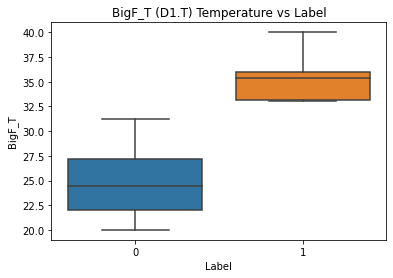

In [23]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Label', y='BigF_T')
plt.title("BigF_T (D1.T) Temperature vs Label")
plt.show()

=== Comparison Table ===


,Normal_mean,Sick_mean,Mean_Difference,% Mean_Difference,Normal_min,Sick_min,Normal_max,Sick_max,Normal_std,Sick_std
BigF_T,24.607577,34.789805,10.182228,41.378428,20.000872,33.0,31.188138,40.0,2.841107,1.784828
Center_T,27.408941,36.274840,8.865900,32.346743,21.918954,33.0,31.999699,40.0,2.168065,1.504369
Side_T,26.644494,36.092227,9.447734,35.458484,20.726124,33.0,31.394197,40.0,1.932333,1.502257
Temp1,25.866359,35.222743,9.356384,36.172020,21.088889,33.0,30.824138,40.0,2.169216,1.561273
Temp2,26.333211,35.045808,8.712597,33.085966,20.335151,33.0,31.783382,40.0,2.179419,1.667942
BigF_P,1816.934685,2399.347790,582.413105,32.054708,0.000000,0.0,4087.767637,4095.0,1506.251596,1672.661770
Center_P,1973.175954,2226.266761,253.090807,12.826571,0.000000,0.0,4002.481200,4095.0,1599.425699,1796.062598
Side_P,2658.669635,2293.839031,-364.830603,-13.722299,0.000000,0.0,4015.653102,4095.0,1392.445434,1775.980754
Pres1,2611.314191,3097.925083,486.610891,18.634712,0.000000,0.0,4029.571044,4095.0,1390.155476,1332.296395
Pres2,2785.012813,3222.144257,437.131444,15.695850,0.000000,0.0,4019.814109,4095.0,1347.329561,1395.082630


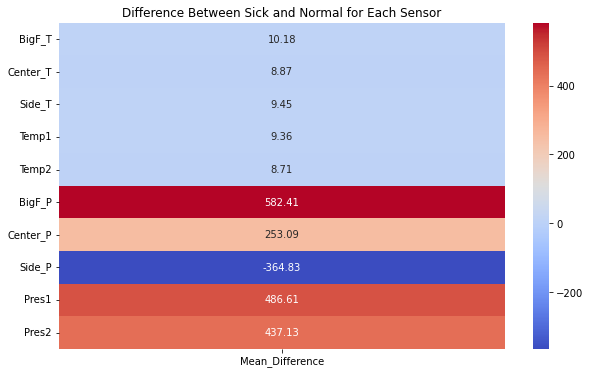

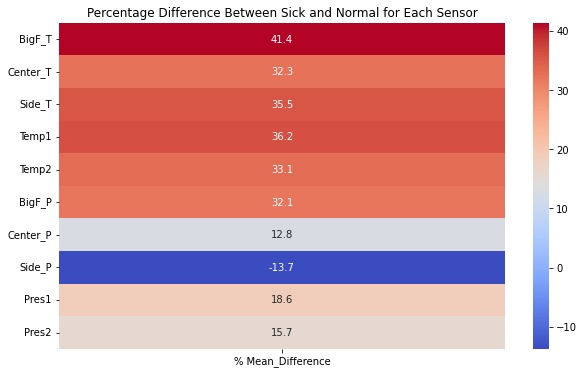

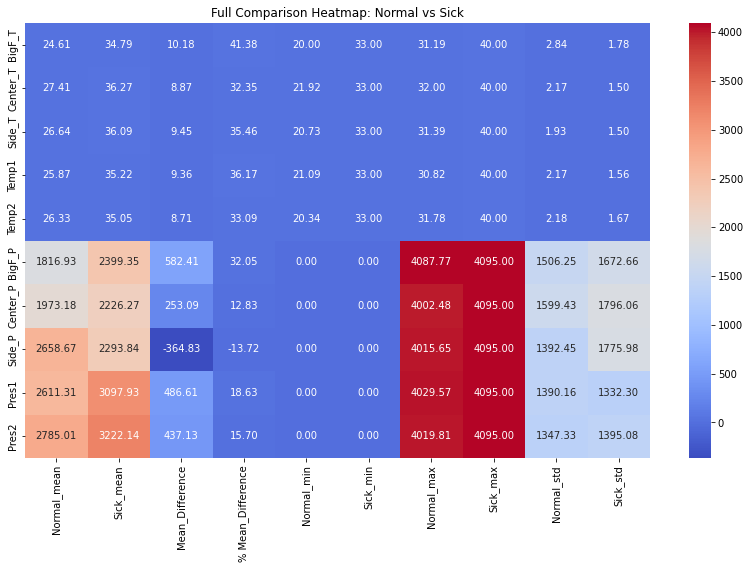

In [24]:
# ===========================
# 1) قائمة السنسورات اللي هنقارنها
# ===========================
sensor_cols = [
    'BigF_T','Center_T','Side_T','Temp1','Temp2',
    'BigF_P','Center_P','Side_P','Pres1','Pres2'
]

# ===========================
# 2) حساب إحصائيات Normal و Sick
# ===========================
normal_stats = df[df['Label'] == 0][sensor_cols].agg(['mean','std','min','max']).T
sick_stats   = df[df['Label'] == 1][sensor_cols].agg(['mean','std','min','max']).T

# ===========================
# 3) جدول المقارنة النهائي
# ===========================
comparison_df = pd.DataFrame({
    'Normal_mean': normal_stats['mean'],
    'Sick_mean': sick_stats['mean'],
    'Mean_Difference': sick_stats['mean'] - normal_stats['mean'],
    '% Mean_Difference': ((sick_stats['mean'] - normal_stats['mean']) / normal_stats['mean']) * 100,
    'Normal_min': normal_stats['min'],
    'Sick_min': sick_stats['min'],
    'Normal_max': normal_stats['max'],
    'Sick_max': sick_stats['max'],
    'Normal_std': normal_stats['std'],
    'Sick_std': sick_stats['std']
})

# نعرض الجدول
print("=== Comparison Table ===")
display(comparison_df)

# ===========================
# 4) HEATMAP 1 — Mean Difference
# ===========================
plt.figure(figsize=(10,6))
sns.heatmap(comparison_df[['Mean_Difference']], annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Difference Between Sick and Normal for Each Sensor")
plt.show()

# ===========================
# 5) HEATMAP 2 — Percentage Difference
# ===========================
plt.figure(figsize=(10,6))
sns.heatmap(comparison_df[['% Mean_Difference']], annot=True, cmap='coolwarm', fmt=".1f")
plt.title("Percentage Difference Between Sick and Normal for Each Sensor")
plt.show()

# ===========================
# 6) HEATMAP 3 — Full Comparison
# ===========================
plt.figure(figsize=(14,8))
sns.heatmap(comparison_df, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Full Comparison Heatmap: Normal vs Sick")
plt.show()


In [25]:
from sklearn.base import BaseEstimator, TransformerMixin
class FeatureEngineer(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.temp_cols = ['Temp1','Temp2','BigF_T','Side_T','Center_T']
        self.pres_cols = ['Pres1','Pres2','BigF_P','Side_P','Center_P']

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()

        # Basic
        df["Temp_mean"] = df[self.temp_cols].mean(axis=1)
        df["Pres_mean"] = df[self.pres_cols].mean(axis=1)

        df["Temp_max"] = df[self.temp_cols].max(axis=1)
        df["Temp_min"] = df[self.temp_cols].min(axis=1)
        df["Temp_range"] = df["Temp_max"] - df["Temp_min"]

        df["Pres_max"] = df[self.pres_cols].max(axis=1)
        df["Pres_min"] = df[self.pres_cols].min(axis=1)
        df["Pres_range"] = df["Pres_max"] - df["Pres_min"]

        # Interaction features
        for t, p in zip(self.temp_cols, self.pres_cols):
            df[f"{t}_x_{p}"] = df[t] * df[p]
            df[f"{t}_div_{p}"] = df[t] / (df[p] + 1)

        # Differences
        df["Pres_diff_big_center"] = df["BigF_P"] - df["Center_P"]
        df["Pres_diff_side_center"] = df["Side_P"] - df["Center_P"]

        df["Temp_diff_big_center"] = df["BigF_T"] - df["Center_T"]
        df["Temp_diff_side_center"] = df["Side_T"] - df["Center_T"]

        # Total pressure
        df["Total_pressure"] = df[self.pres_cols].sum(axis=1)

        return df


In [26]:
from sklearn.model_selection import train_test_split

X = df.drop('Label', axis=1)
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

model = Pipeline([
    ("features", FeatureEngineer()),    
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(
        n_estimators=400,
        n_jobs=-1,
        random_state=42
    )
    )
]
)

model.fit(X_train, y_train)


Pipeline(steps=[('features', FeatureEngineer()), ('scaler', StandardScaler()),
                ('clf',
                 RandomForestClassifier(n_estimators=400, n_jobs=-1,
                                        random_state=42))])

In [28]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[9725    0]
 [   0 9723]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9725
           1       1.00      1.00      1.00      9723

    accuracy                           1.00     19448
   macro avg       1.00      1.00      1.00     19448
weighted avg       1.00      1.00      1.00     19448



In [29]:
from xgboost import XGBClassifier

xgb_model = Pipeline([
    ("features", FeatureEngineer()),
    ("scaler", StandardScaler()),
    ("clf", XGBClassifier(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    ))
])

xgb_model.fit(X_train, y_train)


Pipeline(steps=[('features', FeatureEngineer()), ('scaler', StandardScaler()),
                ('clf',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=150, n_jobs=-1,
                               num_parallel_tree=None, random_state=42, ...))])

In [30]:
y_pred = xgb_model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[9725    0]
 [   0 9723]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9725
           1       1.00      1.00      1.00      9723

    accuracy                           1.00     19448
   macro avg       1.00      1.00      1.00     19448
weighted avg       1.00      1.00      1.00     19448



In [31]:
ran = df.sample(30)   
ran_raw = ran[['Temp1','Temp2','BigF_T','Side_T','Center_T',
               'Pres1','Pres2','BigF_P','Side_P','Center_P']]

y_p=xgb_model.predict(ran_raw)
print(y_p)

[1 1 0 0 0 1 1 0 1 1 0 1 1 1 1 0 1 1 1 0 1 0 1 1 1 0 0 1 0 1]


In [32]:
true_labels = ran['Label']      
predicted = xgb_model.predict(ran_raw)

accuracy = (true_labels.values == predicted).mean()
print("Accuracy on random sample:", accuracy)


Accuracy on random sample: 1.0


In [33]:
# import pickle

# with open("medical_model.pkl", "wb") as file:
#     pickle.dump(model, file)

# print("Model Saved Successfully ✔")
